# The Refund Window

Steam lets you refund any game played for less than two hours. It's a consumer-friendly policy — but it also creates a deadline. If a game disappoints, you have a narrow window to get your money back, and a decision to make: quietly refund, or fire off a warning to everyone else first.

That deadline leaves a fingerprint on the reviews.

Sort reviewers by how long they had played when they wrote their review, and a stark pattern emerges: **below the two-hour refund line, recommendation rates collapse.** A reviewer who played less than thirty minutes recommends the game barely half the time. Cross two hours, and the rate jumps to a steady ~87% — and stays there, flat, no matter how many hundreds of hours they log afterward.

The effect isn't subtle, and it isn't the work of one or two angry games. As we'll show, it holds *within* nearly every game in the dataset, and a second, independent signal — Steam's own refund flag — corroborates it exactly. This is the clearest example in the report of the headline score hiding a structural story: **the same 87%-positive game contains a sub-population of early, sharply negative reviewers that the number quietly averages away.**

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

import _style
_style.set_style()

reviews = pd.read_parquet("../data/processed/reviews.parquet")
metadata = pd.read_parquet("../data/processed/metadata.parquet")

# playtime at review, in hours — the spine of this chapter
reviews["hours_at_review"] = reviews["playtime_at_review"] / 60

print(f"{len(reviews):,} reviews · overall recommend rate {reviews['voted_up'].mean():.1%}")

298,553 reviews · overall recommend rate 84.8%


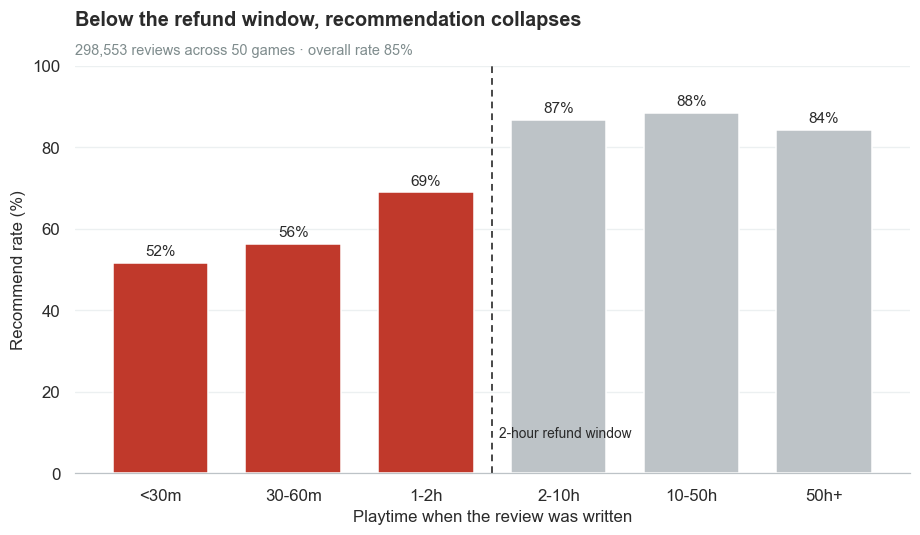

     <30m: 51.6%   (n=4,632)
   30-60m: 56.3%   (n=4,146)
     1-2h: 68.9%   (n=8,183)
    2-10h: 86.7%   (n=72,666)
   10-50h: 88.4%   (n=93,090)
     50h+: 84.2%   (n=115,526)


In [2]:
# The gradient: recommendation rate by playtime-at-review bucket
bins = [0, 30, 60, 120, 600, 3000, np.inf]          # minutes
labels = ["<30m", "30-60m", "1-2h", "2-10h", "10-50h", "50h+"]
reviews["pt_bucket"] = pd.cut(reviews["playtime_at_review"], bins=bins, labels=labels, right=False)

grad = reviews.groupby("pt_bucket", observed=True)["voted_up"].agg(["mean", "size"])
grad["rate"] = grad["mean"] * 100

# first three buckets are inside the 2h refund window -> the finding (accent);
# the rest are past it -> context (grey)
colors = [_style.ACCENT, _style.ACCENT, _style.ACCENT, _style.GREY, _style.GREY, _style.GREY]

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar(grad.index.astype(str), grad["rate"], color=colors, width=0.72)
ax.bar_label(bars, fmt="%.0f%%", padding=3, fontsize=10, color=_style.INK)

# the 2-hour refund boundary, between the 1-2h and 2-10h bars
ax.axvline(2.5, color=_style.INK, linestyle=(0, (4, 3)), linewidth=1.1)
ax.text(2.55, 8, "2-hour refund window", color=_style.INK, fontsize=9, va="bottom")

ax.set_ylim(0, 100)
ax.set_ylabel("Recommend rate (%)")
ax.set_xlabel("Playtime when the review was written")
ax.set_title("Below the refund window, recommendation collapses\n",
             loc="left", fontsize=13, fontweight="bold")
ax.text(0, 1.02,
        f"{len(reviews):,} reviews across 50 games · overall rate {reviews['voted_up'].mean():.0%}",
        transform=ax.transAxes, fontsize=9.5, color=_style.GREY_DARK, va="bottom")
plt.show()

# the numbers behind the chart, stated cleanly
for b in labels:
    r = grad.loc[b]
    print(f"  {b:>7}: {r['rate']:.1f}%   (n={int(r['size']):,})")

## Does it hold inside individual games?

A pooled gradient like this could, in principle, be an illusion of composition — if the sub-two-hour reviews happened to come from the worst games in the set, we'd see exactly this pattern without any real refund-window effect. So we apply the test from the methodology chapter: does the gap survive *within* each game?

For every game with enough reviews on both sides of the two-hour line, we compare its own early reviewers to its own established ones. If the effect is real, it should appear again and again, game by game. In the chart that follows, each horizontal bar is one game; bars to the right of zero are games where the effect holds.

45/46 games (98%) show the effect; median within-game gap = 21.9 pts


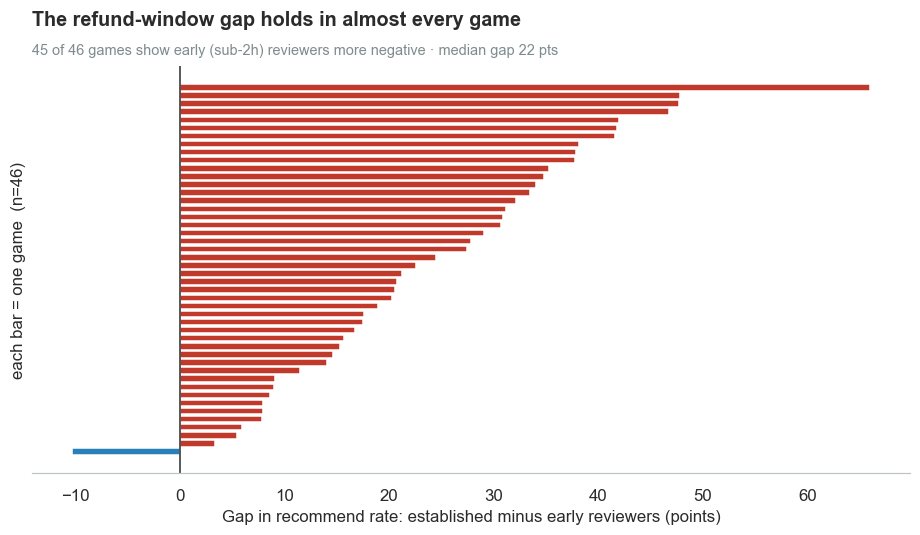

In [3]:
# Within-game validation: compare each game's sub-2h reviewers to its 2h+ reviewers
in_window = reviews["playtime_at_review"] < 120        # under 2 hours

# voted_up is binary -> use mean (the recommend RATE); median of 0/1 is meaningless
gaps = _style.within_game_gap(reviews, in_window, "voted_up", min_per_side=30, agg="mean")
gaps_pts = gaps * 100                                   # rate difference -> points

n_games = len(gaps_pts)
n_consistent = (gaps_pts > 0).sum()
print(_style.gap_summary(gaps_pts, unit=" pts"))

fig, ax = plt.subplots(figsize=(8.5, 5))
order = gaps_pts.sort_values()
colors = [_style.ACCENT if g > 0 else _style.COUNTER for g in order]
ax.barh(range(len(order)), order.values, color=colors, height=0.8)
ax.axvline(0, color=_style.INK, linewidth=1)
ax.set_yticks([])
ax.set_xlabel("Gap in recommend rate: established minus early reviewers (points)")
ax.set_ylabel(f"each bar = one game  (n={n_games})")
ax.set_title("The refund-window gap holds in almost every game\n", loc="left",
             fontsize=13, fontweight="bold")
ax.text(0, 1.02,
        f"{n_consistent} of {n_games} games show early (sub-2h) reviewers more negative · "
        f"median gap {gaps_pts.median():.0f} pts",
        transform=ax.transAxes, fontsize=9.5, color=_style.GREY_DARK, va="bottom")
plt.show()

## A second, independent signal: the refund flag

The playtime gradient is one line of evidence. Steam hands us another, completely independent one: each review carries a flag for whether the reviewer **actually refunded** the game (and later re-bought or kept reviewing access). These are the people who literally used the refund window.

If the refund-deadline story is right, refunded reviewers should look extreme on both axes — clustered inside the refund window, and overwhelmingly negative. They are.

refunded reviews: 3,952 (1.3% of all)
  median playtime at review: 112 min  (1.9h)
  recommend rate: 20.5%   vs 84.8% overall


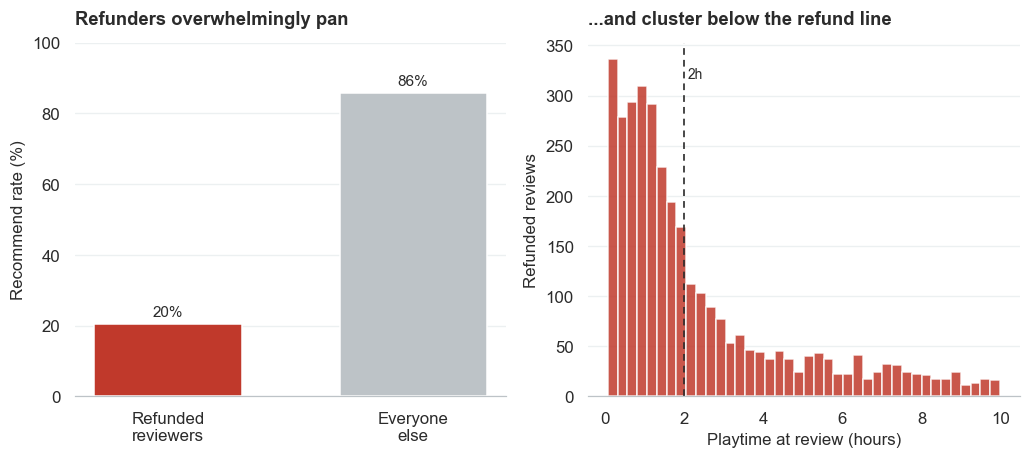

In [4]:
# The refund flag — an independent corroboration of the playtime story
refunded = reviews["refunded"] == True

n_ref = int(refunded.sum())
ref_rate = reviews.loc[refunded, "voted_up"].mean() * 100
ref_median_pt = reviews.loc[refunded, "playtime_at_review"].median()
base_rate = reviews["voted_up"].mean() * 100

print(f"refunded reviews: {n_ref:,} ({refunded.mean():.1%} of all)")
print(f"  median playtime at review: {ref_median_pt:.0f} min  ({ref_median_pt/60:.1f}h)")
print(f"  recommend rate: {ref_rate:.1f}%   vs {base_rate:.1f}% overall")

# visualize the two contrasts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.3))

# left: recommend rate, refunded vs everyone
ax1.bar(["Refunded\nreviewers", "Everyone\nelse"],
        [ref_rate, reviews.loc[~refunded, "voted_up"].mean()*100],
        color=[_style.ACCENT, _style.GREY], width=0.6)
ax1.bar_label(ax1.containers[0], fmt="%.0f%%", padding=3, fontsize=10)
ax1.set_ylim(0, 100); ax1.set_ylabel("Recommend rate (%)")
ax1.set_title("Refunders overwhelmingly pan", loc="left", fontsize=12)

# right: where their playtime sits — a small histogram with the 2h line
pt_hours = reviews.loc[refunded, "playtime_at_review"] / 60
ax2.hist(pt_hours[pt_hours < 10], bins=40, color=_style.ACCENT, alpha=0.85)
ax2.axvline(2, color=_style.INK, linestyle=(0, (4, 3)), linewidth=1.1)
ax2.text(2.1, ax2.get_ylim()[1]*0.9, "2h", color=_style.INK, fontsize=9)
ax2.set_xlabel("Playtime at review (hours)")
ax2.set_ylabel("Refunded reviews")
ax2.set_title("...and cluster below the refund line", loc="left", fontsize=12)

plt.show()

## Does playtime survive when we control for everything else?

The gradient and the refund flag both point the same way, but a skeptic could still object: maybe short-playtime reviews differ in *other* ways — they're written in different languages, get fewer votes, are shorter — and one of *those* is the real driver. Playtime might just be along for the ride.

The way to settle this is a multivariate model: fit a logistic regression predicting whether a review is positive, give it playtime *alongside* the main alternative explanations, and see whether playtime still carries weight once the others are accounted for.

This is a confirmatory model, not a predictive product — we care about *which factors matter and in which direction*, not about squeezing out maximum accuracy. We report odds ratios (how each factor shifts the odds of a positive review), check the model against a trivial baseline, and keep the interpretation honest about what a logistic regression can and cannot show.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# --- build the modeling frame ---
df = reviews.copy()
df["review_len"] = df["review"].str.len().fillna(0)
df["log_playtime"] = np.log1p(df["playtime_at_review"])   # heavy right-skew -> log
df["log_review_len"] = np.log1p(df["review_len"])
df["log_votes_up"] = np.log1p(df["votes_up"])
df["has_funny"] = (df["votes_funny"] >= 1).astype(int)
df["app_id"] = df["app_id"].astype(str)                    # categorical for OHE
df = df.dropna(subset=["voted_up", "log_playtime"])

num_feats = ["log_playtime", "log_review_len", "log_votes_up", "has_funny"]
X = df[num_feats + ["app_id"]]
y = df["voted_up"].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=42, stratify=y)

# scale numerics; one-hot the game (fixed effects); logistic regression
pre = ColumnTransformer([
    ("num", StandardScaler(), num_feats),
    ("game", OneHotEncoder(handle_unknown="ignore"), ["app_id"]),
])
model = make_pipeline(pre, LogisticRegression(max_iter=2000, C=1.0))
model.fit(X_tr, y_tr)

# --- evaluation against a trivial baseline ---
auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
baseline = max(y.mean(), 1 - y.mean())     # "always predict majority class"
print(f"Test AUC: {auc:.3f}   (baseline majority-class accuracy: {baseline:.1%})")

# --- odds ratios for the substantive predictors (not the 50 game dummies) ---
logreg = model.named_steps["logisticregression"]
coefs = logreg.coef_[0][:len(num_feats)]    # numerics are first in the transformer
odds = np.exp(coefs)
print("\nOdds ratios (per 1 SD; >1 = more likely positive, <1 = less likely):")
for f, o in sorted(zip(num_feats, odds), key=lambda t: t[1]):
    arrow = "↓" if o < 1 else "↑"
    print(f"  {f:>16}: {o:5.2f}  {arrow}")

Test AUC: 0.869   (baseline majority-class accuracy: 84.8%)

Odds ratios (per 1 SD; >1 = more likely positive, <1 = less likely):
      log_votes_up:  0.58  ↓
    log_review_len:  0.71  ↓
         has_funny:  0.87  ↓
      log_playtime:  1.45  ↑


The model is unambiguous. Of the factors considered, **playtime is the only one that pushes a review toward positive — and it pushes hardest.** Holding the game fixed and controlling for review length, helpfulness votes, and humor, an additional standard deviation of playtime raises the odds of a positive review by roughly 45%. The other three predictors all lean negative, each echoing a finding from later chapters: longer reviews, more-voted reviews, and "funny" reviews all skew critical.

Crucially, playtime survives *with game held constant*. The effect isn't an illusion created by short-playtime reviews piling up in worse games — within the same game, the reviewer who played longer is meaningfully more likely to recommend it. The test AUC of 0.869, against a majority-class baseline of 85%, confirms these few structural features carry real signal — though we note the model is built to *explain*, not to predict: its value is the direction and size of the coefficients, not its use as a recommender.

## What it means

Four independent lines of evidence converge. The recommendation rate climbs steeply across the sub-two-hour buckets and then locks flat. The gap holds within 45 of 46 games. Steam's own refund flag isolates a group that is both extremely negative and clustered inside the refund window. And a multivariate model confirms playtime predicts sentiment even with game, length, votes, and humor controlled.

**The two-hour refund window leaves a clear fingerprint: reviewers who write before it closes are far harsher than those who write after.**

What we *cannot* say is exactly *why*. Two mechanisms are consistent with this pattern, and observational data cannot fully separate them. The first is **deadline pressure**: a disappointed player, facing a closing refund window, plays briefly and fires off a warning before getting their money back. The second is **selection**: players who would dislike a game anyway tend to quit early, so short playtime and negativity share a common cause — a bad fit — rather than one causing the other.

The data leans toward the first without proving it. Pure selection would predict a smooth relationship between playtime and sentiment; instead we see a sharp change of regime right at the two-hour line, with a flat plateau on the far side — a discontinuity that aligns suspiciously well with the refund boundary rather than with any natural breakpoint in how much people enjoy games. Suspicious alignment is not proof, and we don't claim more than the data supports. But the fingerprint is unmistakable, whatever the hand that left it.